In [3]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 更新为 PPMI 的输入输出路径
RAW_KG_PATH = "kg.csv"
SEED_CSV_PATH = "PPMI_Seed_DementiaHKG.csv"
OUTPUT_HKG_PATH = "PPMI_DementiaHKG_PrimeKG_Sub.csv"

def build_dementia_hkg_ppmi():
    print("==================================================")
    print("🏗️ 阶段 2: 开始构建 DementiaHKG (PPMI外部精炼子图) - 引入二跳与动态剪枝...")
    
    try:
        seed_df = pd.read_csv(SEED_CSV_PATH)
        print(f"   ✅ 成功加载种子文件: {SEED_CSV_PATH}")
    except FileNotFoundError:
        print(f"   ❌ 找不到 {SEED_CSV_PATH}，请先运行第一阶段的脚本。")
        return

    # 将 NACC_Feature 替换为 PPMI_Feature
    valid_seeds_df = seed_df[~seed_df['PPMI_Feature'].str.contains("BLACKLIST")]
    target_nodes = set(valid_seeds_df['PrimeKG_Node'].unique())
    print(f"   🎯 激活白名单种子节点共: {len(target_nodes)} 个。")

    blacklist_types = set(seed_df[seed_df['PPMI_Feature'] == 'BLACKLIST_TYPE']['PrimeKG_Node'])
    blacklist_rels = set(seed_df[seed_df['PPMI_Feature'] == 'BLACKLIST_REL']['PrimeKG_Node'])

    print("\n   ⏳ 正在读取庞大的 PrimeKG 原始图谱，请稍候...")
    kg_df = pd.read_csv(RAW_KG_PATH, low_memory=False)

    print("\n==================================================")
    print("🚶‍♂️ 步骤 1: 提取核心 1-hop 邻居...")
    mask_1hop = (kg_df['x_name'].isin(target_nodes)) | (kg_df['y_name'].isin(target_nodes))
    subgraph_1hop = kg_df[mask_1hop].copy()

    print("\n🧼 步骤 2: 执行 1-hop 黑名单免疫清洗...")
    mask_valid_types = (~subgraph_1hop['x_type'].isin(blacklist_types)) & \
                       (~subgraph_1hop['y_type'].isin(blacklist_types))
    mask_valid_rels = ~subgraph_1hop['relation'].isin(blacklist_rels)
    clean_1hop = subgraph_1hop[mask_valid_types & mask_valid_rels].copy()
    print(f"   👉 清洗后剩余核心 1-hop 医疗边: {len(clean_1hop)} 条")

    print("\n✂️ 步骤 3: 引入 2-hop 游走并执行基于节点全局重要度的 Top-6 智能截断...")
    
    nodes_1hop = set(clean_1hop['x_name']).union(set(clean_1hop['y_name']))

    mask_2hop_x = kg_df['x_name'].isin(nodes_1hop) & (~kg_df['y_name'].isin(target_nodes))
    mask_2hop_y = kg_df['y_name'].isin(nodes_1hop) & (~kg_df['x_name'].isin(target_nodes))
    candidates_2hop = kg_df[mask_2hop_x | mask_2hop_y].copy()

    candidates_2hop = candidates_2hop[
        (~candidates_2hop['x_type'].isin(blacklist_types)) &
        (~candidates_2hop['y_type'].isin(blacklist_types)) &
        (~candidates_2hop['relation'].isin(blacklist_rels))
    ]

    candidates_2hop['source_node'] = np.where(candidates_2hop['x_name'].isin(nodes_1hop), candidates_2hop['x_name'], candidates_2hop['y_name'])
    candidates_2hop['target_node'] = np.where(candidates_2hop['x_name'].isin(nodes_1hop), candidates_2hop['y_name'], candidates_2hop['x_name'])

    print("   ⚖️ 正在计算 2-hop 节点与 PPMI 核心子图的拓扑契合度...")
    
    global_degree_x = kg_df.groupby('x_name').size()
    global_degree_y = kg_df.groupby('y_name').size()
    global_degree = global_degree_x.add(global_degree_y, fill_value=0)
    candidates_2hop['target_global_degree'] = candidates_2hop['target_node'].map(global_degree).fillna(1)
    
    local_relevance = candidates_2hop.groupby('target_node')['source_node'].nunique()
    candidates_2hop['local_relevance'] = candidates_2hop['target_node'].map(local_relevance)
    
    # 调整变量名为 ppmi_relevance
    candidates_2hop['ppmi_relevance'] = candidates_2hop['local_relevance'] / np.log1p(candidates_2hop['target_global_degree'])

    candidates_2hop = candidates_2hop.sort_values(by=['source_node', 'ppmi_relevance', 'target_node'], ascending=[True, False, True])
    
    pruned_2hop = candidates_2hop.groupby('source_node').head(6).drop(columns=['source_node', 'target_node', 'ppmi_relevance', 'local_relevance', 'target_global_degree'])
    
    print(f"   👉 经过重要度排序与 Top-6 截断后，保留高质量 2-hop 扩展边: {len(pruned_2hop)} 条")

    print("\n==================================================")
    print("💾 步骤 4: 组装并导出最终图谱...")
    
    final_hkg = pd.concat([clean_1hop, pruned_2hop]).drop_duplicates()
    final_hkg.to_csv(OUTPUT_HKG_PATH, index=False, encoding='utf-8')
    
    print(f"   🎉 构建成功！最终 DementiaHKG 外部子图包含: {len(final_hkg)} 条边。")
    print(f"   📄 文件已保存至: {OUTPUT_HKG_PATH}")
    
if __name__ == "__main__":
    build_dementia_hkg_ppmi()

🏗️ 阶段 2: 开始构建 DementiaHKG (PPMI外部精炼子图) - 引入二跳与动态剪枝...
   ✅ 成功加载种子文件: PPMI_Seed_DementiaHKG.csv
   🎯 激活白名单种子节点共: 17 个。

   ⏳ 正在读取庞大的 PrimeKG 原始图谱，请稍候...

🚶‍♂️ 步骤 1: 提取核心 1-hop 邻居...

🧼 步骤 2: 执行 1-hop 黑名单免疫清洗...
   👉 清洗后剩余核心 1-hop 医疗边: 4562 条

✂️ 步骤 3: 引入 2-hop 游走并执行基于节点全局重要度的 Top-6 智能截断...
   ⚖️ 正在计算 2-hop 节点与 PPMI 核心子图的拓扑契合度...
   👉 经过重要度排序与 Top-6 截断后，保留高质量 2-hop 扩展边: 10193 条

💾 步骤 4: 组装并导出最终图谱...
   🎉 构建成功！最终 DementiaHKG 外部子图包含: 13050 条边。
   📄 文件已保存至: PPMI_DementiaHKG_PrimeKG_Sub.csv


In [6]:
import pandas as pd
import numpy as np
import json
import warnings

warnings.filterwarnings('ignore')

# ================= ⚡ 配置区 =================
PPMI_DATA_PATH = "PPMI诊断.csv"  # 请确认你的实际数据表名称
SEED_CSV_PATH = "PPMI_Seed_DementiaHKG.csv"
REFINED_KG_PATH = "PPMI_DementiaHKG_PrimeKG_Sub.csv"

OUTPUT_GRAPH_PATH = "PPMI-DementiaHKG-G.csv"
OUTPUT_DICT_PATH = "PPMI-DementiaHKG-Entities.json"
OUTPUT_SPLIT_PATH = "PPMI_Dataset_Split.csv"

MAX_SEQ_LEN = 35
PAD_TOKEN = "[PAD]"

def build_patient_mapping_ppmi():
    print("==================================================")
    print("🔗 阶段 3: 构建患者动态映射与客观图谱格式化 (已省略常模计算)...")

    # 1. 提取图谱结构
    try:
        kg_df = pd.read_csv(REFINED_KG_PATH)
        triplets_df = kg_df[['x_name', 'relation', 'y_name']].copy()
        triplets_df.columns = ['head', 'relation', 'tail']
        
        triplets_df.to_csv(OUTPUT_GRAPH_PATH, index=False, encoding='utf-8')
        print(f"   ✅ 标准化图谱已生成: {OUTPUT_GRAPH_PATH} (共 {len(triplets_df)} 条边)")
        print("   🔒 [安全检查]: 该图谱中不存在任何患者节点，已彻底阻断 Transductive 泄露。")
    except FileNotFoundError:
        print(f"   ❌ 找不到 {REFINED_KG_PATH}，请确保上一阶段已成功运行。")
        return

    # 2. 加载映射字典
    seed_df = pd.read_csv(SEED_CSV_PATH)
    # PPMI 的特征映射类别在 Step2 中定义为 Phenotype
    mapping_df = seed_df[seed_df['Category'] == 'Phenotype'] 
    ppmi_to_pkg_map = dict(zip(mapping_df['PPMI_Feature'], mapping_df['PrimeKG_Node']))
    print(f"\n   📊 成功加载 {len(ppmi_to_pkg_map)} 条临床特征映射规则。")

    # 3. 加载完整数据集
    try:
        ppmi_df = pd.read_csv(PPMI_DATA_PATH, low_memory=False)
    except FileNotFoundError:
        print(f"   ❌ 找不到患者数据 {PPMI_DATA_PATH}。")
        return

    print("\n   🔀 正在执行安全的随机数据集划分 (Train: 70%, Val: 10%, Test: 20%)...")
    np.random.seed(42) 
    
    # 获取所有有效患者 ID，兼容 Subject 或 PATNO
    def get_pid(row):
        if 'Subject' in row and pd.notna(row['Subject']): return str(row['Subject']).strip()
        if 'PATNO' in row and pd.notna(row['PATNO']): return str(row['PATNO']).strip()
        return None

    ppmi_df['patient_id_temp'] = ppmi_df.apply(get_pid, axis=1)
    valid_pids = ppmi_df['patient_id_temp'].dropna().unique()
    
    np.random.shuffle(valid_pids)
    n_total = len(valid_pids)
    n_train = int(n_total * 0.7)
    n_val = int(n_total * 0.1)
    
    train_ids = set(valid_pids[:n_train])
    val_ids = set(valid_pids[n_train:n_train+n_val])
    test_ids = set(valid_pids[n_train+n_val:])
    
    split_records = []
    for pid in valid_pids:
        split_records.append({'PatientID': pid, 'Split': 'Train' if pid in train_ids else ('Val' if pid in val_ids else 'Test')})
    pd.DataFrame(split_records).to_csv(OUTPUT_SPLIT_PATH, index=False)
    print(f"   ✅ 数据集划分索引已保存至: {OUTPUT_SPLIT_PATH}")

    # 省略常模计算，使用直接的异常判定逻辑
    def check_abnormal(val):
        return val > 0

    patient_entities = {}
    valid_mapped_patients = 0
    total_features_mapped = 0

    print(f"\n   ⏳ 正在为所有患者建立图谱实体序列...")
    
    for index, row in ppmi_df.iterrows():
        patient_id = row.get('patient_id_temp')
        if not patient_id: continue

        active_nodes = []
        for col_name, val in row.items():
            if col_name in ppmi_to_pkg_map:
                val_str = str(val).strip().lower()
                if pd.notna(val) and val_str not in ['', 'nan', '-4', '-1']:
                    try:
                        num_val = float(val)
                        if check_abnormal(num_val):
                            primekg_node = ppmi_to_pkg_map[col_name]
                            active_nodes.append(primekg_node)
                            total_features_mapped += 1
                    except ValueError:
                        pass

        active_nodes = list(set(active_nodes))
        seq_len = len(active_nodes)
        
        if seq_len > MAX_SEQ_LEN:
            active_nodes = active_nodes[:MAX_SEQ_LEN]
            attention_mask = [1] * MAX_SEQ_LEN
        else:
            pad_length = MAX_SEQ_LEN - seq_len
            attention_mask = [1] * seq_len + [0] * pad_length
            active_nodes = active_nodes + [PAD_TOKEN] * pad_length

        patient_entities[patient_id] = {
            "input_nodes": active_nodes,
            "attention_mask": attention_mask
        }
        
        if seq_len > 0:
            valid_mapped_patients += 1

    with open(OUTPUT_DICT_PATH, 'w', encoding='utf-8') as f:
        json.dump(patient_entities, f, indent=4, ensure_ascii=False)

    print("\n==================================================")
    print("💾 阶段 3 任务完成！")
    print(f"   👨‍⚕️ 处理患者总数: {len(ppmi_df)}")
    print(f"   🔗 成功映射患者数: {valid_mapped_patients}")
    print(f"   📈 映射特征总次: {total_features_mapped}")
    print(f"   📄 图谱序列已保存至: {OUTPUT_DICT_PATH}")
    print("==================================================")

if __name__ == "__main__":
    build_patient_mapping_ppmi()

🔗 阶段 3: 构建患者动态映射与客观图谱格式化 (已省略常模计算)...
   ✅ 标准化图谱已生成: PPMI-DementiaHKG-G.csv (共 13050 条边)
   🔒 [安全检查]: 该图谱中不存在任何患者节点，已彻底阻断 Transductive 泄露。

   📊 成功加载 38 条临床特征映射规则。

   🔀 正在执行安全的随机数据集划分 (Train: 70%, Val: 10%, Test: 20%)...
   ✅ 数据集划分索引已保存至: PPMI_Dataset_Split.csv

   ⏳ 正在为所有患者建立图谱实体序列...

💾 阶段 3 任务完成！
   👨‍⚕️ 处理患者总数: 409
   🔗 成功映射患者数: 230
   📈 映射特征总次: 864
   📄 图谱序列已保存至: PPMI-DementiaHKG-Entities.json


📊 步骤 1: 统计图谱规模并构建 ID 映射字典...
   📈 [DementiaHKG 规模统计]:
      - 实体节点总数 (Entities): 2497
      - 关系类型总数 (Relations): 17
      - 三元组边总数 (Triplets): 13050

🚀 步骤 2: 启动 DistMult 模型训练 (设备: cpu)...
   - Epoch [001/150] | Train Loss: 0.9975
   - Epoch [010/150] | Train Loss: 0.0182
   - Epoch [020/150] | Train Loss: 0.0152
   - Epoch [030/150] | Train Loss: 0.0138
   - Epoch [040/150] | Train Loss: 0.0161
   - Epoch [050/150] | Train Loss: 0.0124
   - Epoch [060/150] | Train Loss: 0.0172
   - Epoch [070/150] | Train Loss: 0.0151
   - Epoch [080/150] | Train Loss: 0.0145
   - Epoch [090/150] | Train Loss: 0.0159
   - Epoch [100/150] | Train Loss: 0.0135
   - Epoch [110/150] | Train Loss: 0.0127
   - Epoch [120/150] | Train Loss: 0.0137
   - Epoch [130/150] | Train Loss: 0.0151
   - Epoch [140/150] | Train Loss: 0.0144
   - Epoch [150/150] | Train Loss: 0.0131

💾 步骤 3: 提取并保存实体向量矩阵及 Loss 历史...
   ✅ KGE 训练完成！
   📐 导出的向量矩阵形状: (2497, 128)
   📄 文件已保存至: PPMI-DementiaHKG-Embeddings.npy & PPMI-DementiaHKG

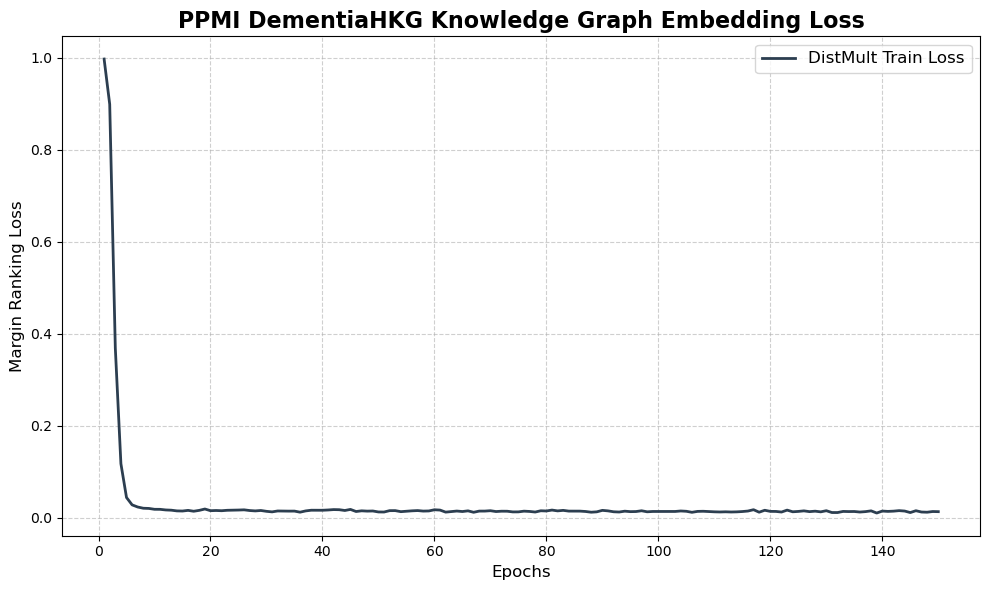

In [7]:
import pandas as pd
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ================= ⚡ 配置区 =================
GRAPH_PATH = "PPMI-DementiaHKG-G.csv"
OUTPUT_ENT2ID = "PPMI-DementiaHKG-Entity2ID.json"
OUTPUT_REL2ID = "PPMI-DementiaHKG-Relation2ID.json"
OUTPUT_EMBED = "PPMI-DementiaHKG-Embeddings.npy"
OUTPUT_LOSS_HISTORY = "PPMI-DementiaHKG-LossHistory.json" 
OUTPUT_PLOT_PATH = "PPMI-DementiaHKG-LossCurve.png"

# 超参数设置
EMBED_DIM = 128
NUM_EPOCHS = 150
BATCH_SIZE = 512
LR = 0.005
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= 1. 统计与索引构建 =================
def analyze_graph_and_build_dicts():
    print("==================================================")
    print("📊 步骤 1: 统计图谱规模并构建 ID 映射字典...")
    
    if not os.path.exists(GRAPH_PATH):
        raise FileNotFoundError(f"❌ 找不到图谱文件: {GRAPH_PATH}")
        
    df = pd.read_csv(GRAPH_PATH)
    
    entities = sorted(list(set(df['head'].unique()) | set(df['tail'].unique())))
    relations = sorted(list(df['relation'].unique()))
    
    entity2id = {ent: idx for idx, ent in enumerate(entities)}
    relation2id = {rel: idx for idx, rel in enumerate(relations)}
    
    with open(OUTPUT_ENT2ID, 'w', encoding='utf-8') as f:
        json.dump(entity2id, f, ensure_ascii=False, indent=4)
    with open(OUTPUT_REL2ID, 'w', encoding='utf-8') as f:
        json.dump(relation2id, f, ensure_ascii=False, indent=4)
        
    print(f"   📈 [DementiaHKG 规模统计]:")
    print(f"      - 实体节点总数 (Entities): {len(entities)}")
    print(f"      - 关系类型总数 (Relations): {len(relations)}")
    print(f"      - 三元组边总数 (Triplets): {len(df)}")
    
    return df, entity2id, relation2id

# ================= 2. 数据集与模型定义 =================
class PureKGDataset(Dataset):
    def __init__(self, triplets_df, entity2id, relation2id):
        self.triplets = []
        for _, row in triplets_df.iterrows():
            h = entity2id[row['head']]
            r = relation2id[row['relation']]
            t = entity2id[row['tail']]
            self.triplets.append((h, r, t))
        self.triplets = torch.LongTensor(self.triplets)
        
    def __len__(self):
        return len(self.triplets)
    
    def __getitem__(self, idx):
        return self.triplets[idx]

class DistMult(nn.Module):
    def __init__(self, num_entities, num_relations, embed_dim):
        super(DistMult, self).__init__()
        self.num_entities = num_entities
        self.ent_emb = nn.Embedding(num_entities, embed_dim)
        self.rel_emb = nn.Embedding(num_relations, embed_dim)
        
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)
        self.criterion = nn.MarginRankingLoss(margin=1.0)

    def forward(self, h, r, t):
        h_e, r_e, t_e = self.ent_emb(h), self.rel_emb(r), self.ent_emb(t)
        return torch.sum(h_e * r_e * t_e, dim=1)

    def calculate_loss(self, h, r, t):
        batch_size = h.size(0)
        neg_t = torch.randint(0, self.num_entities, (batch_size,), device=h.device)
        pos_score = self.forward(h, r, t)
        neg_score = self.forward(h, r, neg_t)
        
        target = torch.ones(batch_size, device=h.device)
        return self.criterion(pos_score, neg_score, target)

# ================= 3. 训练主循环 =================
def train_kge():
    df, entity2id, relation2id = analyze_graph_and_build_dicts()
    
    print("\n==================================================")
    print(f"🚀 步骤 2: 启动 DistMult 模型训练 (设备: {DEVICE})...")
    
    dataset = PureKGDataset(df, entity2id, relation2id)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    model = DistMult(len(entity2id), len(relation2id), EMBED_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    loss_history = [] 
    
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        total_loss = 0
        
        for batch in dataloader:
            batch = batch.to(DEVICE)
            h, r, t = batch[:, 0], batch[:, 1], batch[:, 2]
            
            optimizer.zero_grad()
            loss = model.calculate_loss(h, r, t)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"   - Epoch [{epoch:03d}/{NUM_EPOCHS}] | Train Loss: {avg_loss:.4f}")
            
    print("\n==================================================")
    print("💾 步骤 3: 提取并保存实体向量矩阵及 Loss 历史...")
    embeddings = model.ent_emb.weight.detach().cpu().numpy()
    np.save(OUTPUT_EMBED, embeddings)
    
    with open(OUTPUT_LOSS_HISTORY, 'w', encoding='utf-8') as f:
        json.dump(loss_history, f)
    
    print(f"   ✅ KGE 训练完成！")
    print(f"   📐 导出的向量矩阵形状: {embeddings.shape}")
    print(f"   📄 文件已保存至: {OUTPUT_EMBED} & {OUTPUT_LOSS_HISTORY}")
    print("==================================================")
    
    return loss_history

# ================= 4. 绘制Loss曲线 =================
def plot_loss_curve(losses):
    print("\n==================================================")
    print("📈 步骤 4: 正在绘制 KGE 训练 Loss 收敛曲线...")
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(losses) + 1), losses, color='#2c3e50', linewidth=2, label='DistMult Train Loss')
    
    plt.title('PPMI DementiaHKG Knowledge Graph Embedding Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Margin Ranking Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    plt.savefig(OUTPUT_PLOT_PATH, dpi=300)
    print(f"   ✅ 曲线图已生成，已保存高清大图至: {OUTPUT_PLOT_PATH}")
    print("==================================================")
    plt.show()

if __name__ == "__main__":
    losses = train_kge()
    plot_loss_curve(losses)